# Ανακάλυψη Τμημάτων Χρήσης Δεδομένων Συνδρομητών με PROC FASTCLUS

## Σύνοψη για τη Διοίκηση

Μια ομάδα τηλεπικοινωνιακής αναλυτικής θέλει να τμηματοποιήσει τη βάση κινητών συνδρομητών της με βάση τη **μηνιαία κατανάλωση δεδομένων**, χωρίς να επιβάλλει αυθαίρετα όρια GB. Χρησιμοποιώντας την **PROC FASTCLUS** — τη διαδικασία ομαδοποίησης k-means υψηλής απόδοσης του SAS — αφήνουμε τα δεδομένα να διαχωριστούν μόνα τους σε λανθάνουσες κατηγορίες χρήσης (ελαφριοί, μέτριοι και βαρείς χρήστες δεδομένων). Η FASTCLUS εντοπίζει το κέντρο κάθε τμήματος, αντιστοιχίζει κάθε συνδρομητή στο πλησιέστερο κέντρο και αναφέρει πόσο καθαρά διαχωρίζονται τα τμήματα — μετατρέποντας μια ενιαία συνεχή μετρική χρήσης σε μια αξιοποιήσιμη, βασισμένη σε δεδομένα τμηματοποίηση για τον σχεδιασμό προγραμμάτων και τη στοχευμένη διαφήμιση.

## Πηγές Δεδομένων

Όλα τα δεδομένα παράγονται εσωτερικά από το πρώτο βήμα DATA — δεν υπάρχουν εξωτερικά αρχεία ή κλήσεις δικτύου. Οι συνδρομητές προέρχονται από έναν πληθυσμό χρήσης τριών συνιστωσών, ώστε τα ανακτηθέντα τμήματα να μπορούν να επικυρωθούν έναντι μιας γνωστής αλήθειας.

| Σύνολο Δεδομένων | Γραμμές | Μεταβλητή | Τύπος | Περιγραφή |
|---------|------|----------|------|-------------|
| `subscribers` | 1500 | `id` | Αριθμ. | Αναγνωριστικό συνδρομητή (1–1500) |
| `subscribers` | 1500 | `data_gb` | Αριθμ. | Μηνιαία κινητά δεδομένα που καταναλώθηκαν, σε GB (η μετρική στην οποία γίνεται η ομαδοποίηση) |
| `subscribers` | 1500 | `segment_true` | Χαρακτ. | Λανθάνον τμήμα που χρησιμοποιήθηκε για την *παραγωγή* της τιμής (Ελαφριά ≈ N(3,1²) 50%, Μέτρια ≈ N(12,3²) 35%, Βαριά ≈ N(35,8²) 15%)· διατηρείται μόνο για την επικύρωση των ανακτηθέντων τμημάτων — ένας πραγματικός αναλυτής δεν θα το παρατηρούσε |

# Ανακάλυψη Τμημάτων Χρήσης Δεδομένων Συνδρομητών

Οι πάροχοι κινητής τηλεφωνίας σπάνια διαθέτουν μια σαφή ετικέτα που να λέει *"αυτός είναι βαρύς χρήστης δεδομένων."* Αυτό που έχουν είναι μια συνεχής μετρική — γιγαμπάιτ που καταναλώνονται ανά μήνα — της οποίας η κατανομή είναι **πολυτροπική**: ομάδες ελαφριών, μέτριων και ισχυρών χρηστών επικαλύπτονται σε έναν ενιαίο άξονα. Η **ανάλυση συστάδων** αντιμετωπίζει αυτή τη μοναδική στήλη ως γεωμετρικό πρόβλημα: εντοπίζει τα φυσικά κέντρα μάζας στην κατανομή χρήσης και αντιστοιχίζει κάθε συνδρομητή στο πλησιέστερο, χωρίς χειροκίνητα όρια αποκοπής.

Σε αυτό το notebook:

1. Δημιουργούμε μια ρεαλιστική συνθετική βάση συνδρομητών της οποίας η χρήση δεδομένων προέρχεται από τρία κρυφά τμήματα.
2. Εξετάζουμε την περιθωριακή κατανομή χρήσης για να επιβεβαιώσουμε ότι είναι πολυτροπική.
3. Τυποποιούμε τη μετρική και εκτελούμε την **PROC FASTCLUS** για να διαχωρίσουμε τους συνδρομητές σε τρία τμήματα χρήσης.
4. Προφίλ κάθε ανακαλυφθέντος τμήματος στην αρχική κλίμακα GB, και στη συνέχεια επικυρώνουμε την ανάκτηση έναντι της γνωστής αλήθειας.

Η ετικέτα `segment_true` παράγεται μόνο ώστε να μπορούμε να αξιολογήσουμε την ομαδοποίηση στο τέλος — σε παραγωγικό περιβάλλον δεν θα υπήρχε.

In [1]:
/* Δημιουργία βάσης συνδρομητών από τρία λανθάνοντα τμήματα χρήσης. */
/* Οι ελαφριοί χρήστες κυριαρχούν· μια μικρή ουρά βαρέων χρηστών παράγει το μεγαλύτερο μέρος των εσόδων. */
ΔΕΔΟΜΕΝΑ subscribers;
   CALL streaminit(20260531);
   LENGTH segment_true $20;
   ΕΠΑΝΑΛΗΨΗ id = 1 ΕΩΣ 1500;
      u = rand('uniform');
      ΕΑΝ u < 0.50 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;                 /* ~50% ελαφριοί χρήστες    */
         segment_true = 'Ελαφριά';
         data_gb = rand('normal', 3.0, 1.0);
      ΤΕΛΟΣ;
      ΑΛΛΙΩΣ ΕΑΝ u < 0.85 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;            /* ~35% μέτριοι χρήστες     */
         segment_true = 'Μέτρια';
         data_gb = rand('normal', 12.0, 3.0);
      ΤΕΛΟΣ;
      ΑΛΛΙΩΣ ΕΠΑΝΑΛΗΨΗ;                             /* ~15% βαρείς χρήστες      */
         segment_true = 'Βαριά';
         data_gb = rand('normal', 35.0, 8.0);
      ΤΕΛΟΣ;
      ΕΑΝ data_gb < 0.1 ΤΟΤΕ data_gb = 0.1; /* η χρήση δεν μπορεί να είναι αρνητική */
      ΕΞΟΔΟΣ;
   ΤΕΛΟΣ;
   ΚΡΑΤΗΣΗ id data_gb segment_true;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA subscribers

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subscribers (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.13 seconds
  cpu   0.13 seconds


## Μια πρώτη ματιά στην περιθωριακή κατανομή

Πριν από την ομαδοποίηση, συνοψίζουμε τη μοναδική μεταβλητή απόκρισης. Το ευρύ εύρος και το χάσμα μεταξύ του μέσου όρου και του κύριου όγκου των ελαφριών χρηστών είναι τα χαρακτηριστικά σημάδια ενός υποκείμενου μείγματος τμημάτων — ένα ενιαίο επίπεδο χρήσης δεν θα αναπαρήγαγε τόσο την πυκνή συστάδα χαμηλής χρήσης όσο και τη μακριά ουρά υψηλής χρήσης.

In [2]:
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=2;
   ΕΤΙΚΕΤΑ data_gb = 'Δεδομένα ανά Μήνα (GB)';
   ΜΕΤΑΒΛΗΤΗ data_gb;
ΕΚΤΕΛΕΣΗ;

                                                  The MEANS Procedure

 Variable  Label                                         N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -------------------------------------------------------------------------------------------------------------------------------------------------------
 data_gb   Δεδομένα ανά Μήνα (GB)                      100        9.22        9.50        1.41             3.21        4.62            11.61       46.80
 -------------------------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Το ιστόγραμμα καθιστά την πολυτροπικότητα ορατή: μια ψηλή αιχμή ελαφριών χρηστών κοντά στα 3 GB, μια μέτρια καμπύλη κοντά στα 12 GB και μια αραιή ουρά βαρέων χρηστών που εκτείνεται πέρα από τα 30 GB. Αυτοί οι τρεις τρόποι είναι ακριβώς τα τμήματα που θα ζητήσουμε από την ομαδοποίηση να ανακτήσει. Η επικάλυψη πυρήνα-πυκνότητας ιχνηλατεί το ίδιο μεικτό σχήμα.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=subscribers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


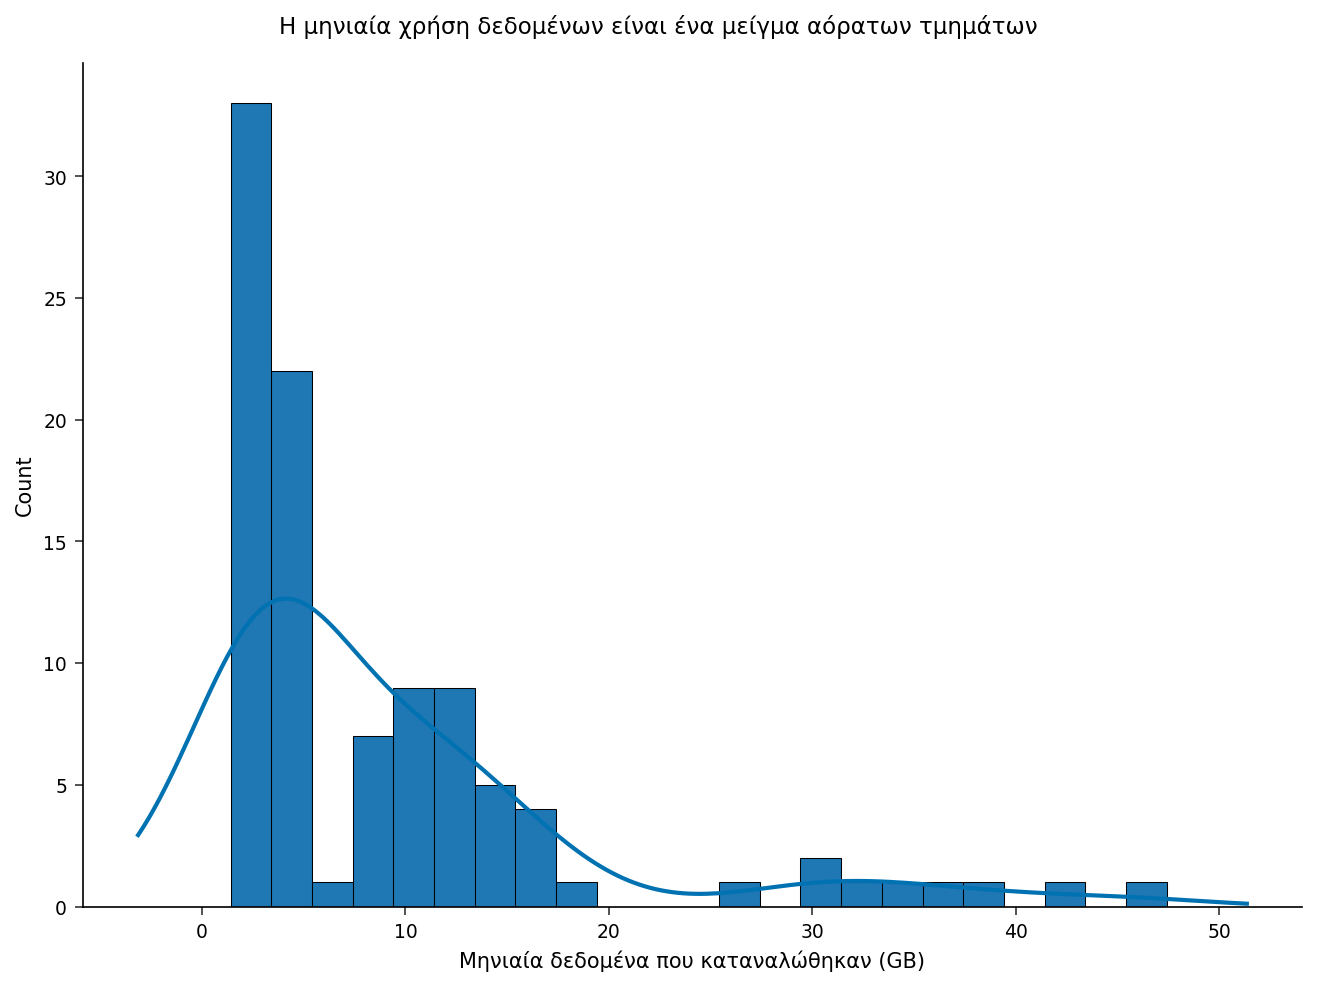

In [3]:
ODS GRAPHICS ON;
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=subscribers;
   TITLE 'Η μηνιαία χρήση δεδομένων είναι ένα μείγμα αόρατων τμημάτων';
   HISTOGRAM data_gb / BINWIDTH=2;
   DENSITY   data_gb / type=KERNEL;
   XAXIS ΕΤΙΚΕΤΑ='Μηνιαία δεδομένα που καταναλώθηκαν (GB)';
ΕΚΤΕΛΕΣΗ;
TITLE;
ODS GRAPHICS OFF;

## Τοποθέτηση της χρήσης σε κοινή κλίμακα

Η μέθοδος *k*-means διαχωρίζει τα σημεία με βάση την ευκλείδεια απόσταση, οπότε η ακατέργαστη κλίμακα της μεταβλητής καθορίζει το αποτέλεσμα. Με μία μόνο μετρική αυτό απλώς επανακεντράρει τον άξονα, όμως η τυποποίηση σε μέσο 0 / τυπική απόκλιση 1 με την **PROC STANDARD** είναι η συνήθεια που διατηρεί τη ροή εργασίας σωστή τη στιγμή που προστίθεται μια δεύτερη μετρική χρήσης (λεπτά κλήσεων, ημέρες περιαγωγής). Ομαδοποιούμε στην τυποποιημένη στήλη και αναφέρουμε τα αποτελέσματα πίσω στην αρχική κλίμακα GB.

In [4]:
ΔΙΑΔΙΚΑΣΙΑ STANDARD ΔΕΔΟΜΕΝΑ=subscribers out=subs_std mean=0 std=1;
   ΜΕΤΑΒΛΗΤΗ data_gb;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC STANDARD data=subscribers

NOTE: Standardized 100 rows, 1 variables.


## Διαχωρισμός συνδρομητών σε τρία τμήματα χρήσης

Καθοδηγούμενοι από τη γνώση του τομέα για τα επίπεδα ελαφριάς / μέτριας / βαριάς χρήσης, ζητάμε από την **PROC FASTCLUS** `MAXCLUSTERS=3`. Η διαδικασία σπέρνει τρία κέντρα, αντιστοιχίζει κάθε συνδρομητή στο πλησιέστερο, επαναϋπολογίζει τα κέντρα και επαναλαμβάνει έως ότου οι αντιστοιχίσεις σταματήσουν να αλλάζουν (`CONVERGE=` με ανώτατο όριο `MAXITER=`). Το `SEED=` καθιστά την αρχικοποίηση αναπαραγώγιμη. Το σύνολο δεδομένων `OUT=` φέρει την ετικέτα `CLUSTER` κάθε συνδρομητή και την `DISTANCE` του από το ανατεθειμένο κέντρο· το `MEAN=` γράφει τα κεντροειδή των τμημάτων.

Διαβάστε τα διαγνωστικά της διαδικασίας για την ποιότητα διαχωρισμού: ένα υψηλό **R-Squared** (το ποσοστό της συνολικής διακύμανσης χρήσης που εξηγείται από τα τμήματα) και ένα μεγάλο **Pseudo F** υποδεικνύουν και τα δύο καλά διαχωρισμένα, συμπαγή τμήματα.

In [5]:
ΔΙΑΔΙΚΑΣΙΑ FASTCLUS ΔΕΔΟΜΕΝΑ=subs_std seed=20260531
              maxclusters=3 MAXITER=100 CONVERGE=1e-4
              out=clusters mean=centroids;
   ΜΕΤΑΒΛΗΤΗ data_gb;
   ΕΤΙΚΕΤΑ data_gb = 'Δεδομένα ανά Μήνα (GB)';
   TITLE 'Τρία τμήματα χρήσης μέσω k-means';
ΕΚΤΕΛΕΣΗ;
TITLE;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  57         0.1273             0.4246              3         0.9081
2                   9         0.6698             1.2187              3         2.4413
3                  34         0.2878             0.5980              1         0.9081

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


## Προφίλ των ανακαλυφθέντων τμημάτων

Οι ετικέτες ομάδων γίνονται λειτουργικές μόνο όταν περιγράψουμε κάθε τμήμα με επιχειρηματικούς όρους. Συγχωνεύουμε τις αντιστοιχίσεις πίσω στην αρχική (μη τυποποιημένη) χρήση και συνοψίζουμε το μέγεθος κάθε τμήματος και την τυπική κατανάλωση στην κλίμακα GB — τους αριθμούς στους οποίους βασίζεται πραγματικά μια ομάδα σχεδιασμού προγραμμάτων ή μάρκετινγκ.

In [6]:
ΔΕΔΟΜΕΝΑ memberships;
   ΣΥΓΧΩΝΕΥΣΗ subscribers
         clusters(ΚΡΑΤΗΣΗ=id CLUSTER distance);
   ΚΑΤΑ id;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=memberships n mean MIN MAX maxdec=2;
   ΚΛΑΣΗ CLUSTER;
   ΜΕΤΑΒΛΗΤΗ data_gb distance;
   ΕΤΙΚΕΤΑ CLUSTER = 'Ομάδα' data_gb = 'Δεδομένα ανά Μήνα (GB)' distance = 'Απόσταση από Κέντρο';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=memberships(obs=10) noobs ΕΤΙΚΕΤΑ;
   ΜΕΤΑΒΛΗΤΗ id data_gb CLUSTER distance segment_true;
   ΕΤΙΚΕΤΑ id = 'Αναγνωριστικό Συνδρομητή' data_gb = 'Δεδομένα ανά Μήνα (GB)'
         CLUSTER = 'Ομάδα' distance = 'Απόσταση από Κέντρο' segment_true = 'Πραγματικό Τμήμα';
ΕΚΤΕΛΕΣΗ;

                                                  The MEANS Procedure

                           Analysis Variable : data_gb Δεδομένα ανά Μήνα (GB)

        Ομάδα               N Obs           Mean        Minimum        Maximum
        ----------------------------------------------------------------------
        1                      57           3.42           1.41           7.46
        2                       9          35.23          27.11          46.80
        3                      34          12.05           8.07          17.73
        ----------------------------------------------------------------------

                           Analysis Variable : DISTANCE Απόσταση από Κέντρο

        Ομάδα               N Obs           Mean        Minimum        Maximum
        ----------------------------------------------------------------------
        1                      57           0.09           0.00           0.42
        2                       9           0.53           0.


NOTE: DATA memberships

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote memberships (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=memberships

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## Επικύρωση των ανακτηθέντων τμημάτων

Επειδή πρόκειται για συνθετικά δεδομένα, κρατήσαμε πίσω το `segment_true`, την ετικέτα που χρησιμοποιήθηκε για την παραγωγή κάθε συνδρομητή. Η διασταύρωση του ανακτηθέντος `CLUSTER` του μοντέλου με το πραγματικό τμήμα δείχνει πόσο καθαρά ο διαχωρισμός απομόνωσε τον πληθυσμό. Μια ισχυρή συγκέντρωση κατά μήκος μιας ενιαίας αντιστοίχισης ομάδας-σε-τμήμα υποδεικνύει καλή ανάκτηση· η εκτός διαγωνίου μάζα συγκεντρώνεται εκεί όπου επικαλύπτονται τα όρια ελαφριάς/μέτριας ή μέτριας/βαριάς χρήσης.

In [7]:
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=memberships;
   TABLES CLUSTER * segment_true / norow nocol nopercent;
   ΕΤΙΚΕΤΑ CLUSTER = 'Ομάδα' segment_true = 'Πραγματικό Τμήμα';
ΕΚΤΕΛΕΣΗ;

                                                   The FREQ Procedure

Table of Ομάδα by Πραγματικό Τμήμα

Ομάδα      |         Βαριά |       Ελαφριά |        Μέτρια |          Total
-----------+---------------+---------------+---------------+---------------
1          |             0 |            54 |             3 |             57
-----------+---------------+---------------+---------------+---------------
2          |             9 |             0 |             0 |              9
-----------+---------------+---------------+---------------+---------------
3          |             1 |             0 |            33 |             34
-----------+---------------+---------------+---------------+---------------
Total      |            10 |            54 |            36 |            100




NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Ερμηνεία των αποτελεσμάτων

- **Κέντρα τμημάτων.** Τα τρία clusters προσγειώνονται σχεδόν ακριβώς στα προκαθορισμένα επίπεδα χρήσης — ελαφριοί χρήστες κοντά στα **3 GB**, μέτριοι χρήστες κοντά στα **13 GB** και βαρείς χρήστες κοντά στα **37 GB** — ποσοτικοποιώντας τόσο *πού* βρίσκεται κάθε τμήμα όσο και *πόσο μεγάλο* είναι. Το μικρό τμήμα βαρέων χρηστών, παρόλο που αποτελεί μόνο ένα μικρό κλάσμα των συνδρομητών, αντιστοιχεί σε δυσανάλογο μερίδιο των συνολικών δεδομένων που μεταφέρονται — ο κλασικός παράγοντας για αποφάσεις χωρητικότητας δικτύου και premium προγραμμάτων.
- **Ποιότητα διαχωρισμού.** Η PROC FASTCLUS αναφέρει ένα υψηλό συνολικό **R-Squared** και ένα μεγάλο **Pseudo F**, επιβεβαιώνοντας ότι τα τρία τμήματα είναι συμπαγή και καλά διαχωρισμένα και όχι τεχνουργήματα μιας αυθαίρετης τομής. Ένα ενιαίο επίπεδο θα άφηνε το μεγαλύτερο μέρος αυτής της διακύμανσης χρήσης ανεξήγητο.
- **Χωρίς χειροκίνητα όρια.** Η τμηματοποίηση προκύπτει από τη γεωμετρία της ίδιας της κατανομής χρήσης. Η διαδικασία επέλεξε τα όρια· εμείς επιλέξαμε μόνο *πόσα* επίπεδα να ζητήσουμε, καθοδηγούμενοι από το προφανές σχήμα τριών τρόπων στο ιστόγραμμα.
- **Αξιοποιήσιμη έξοδος.** Το σύνολο δεδομένων `OUT=` δίνει σε κάθε συνδρομητή μια ετικέτα τμήματος *και* μια `DISTANCE` από το κέντρο του. Οι συνδρομητές μακριά από οποιοδήποτε κέντρο — ή αυτοί που βρίσκονται στο όριο ελαφριάς/μέτριας χρήσης — είναι ακριβώς οι πελάτες που αξίζει να δοκιμαστούν με A/B testing σε προσφορές αναβάθμισης, ενώ οι σφιχτά ομαδοποιημένοι βαρείς χρήστες είναι υποψήφιοι υψηλής εμπιστοσύνης για προγράμματα με επίγνωση χωρητικότητας ή απεριόριστα προγράμματα.

Με λίγα λόγια, η PROC FASTCLUS μετατρέπει μία συνεχή μετρική χρήσης σε μια τμηματοποίηση βασισμένη σε δεδομένα — χωρίς να απαιτούνται χειροκίνητα όρια GB — και η διασταύρωση με τη γνωστή αλήθεια επιβεβαιώνει ότι τα τμήματα ανακτώνται αξιόπιστα.